In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
df = pd.read_csv("titanic_dataset_clean.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  embark_town  891 non-null    object 
 12  alive        891 non-null    object 
 13  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(6)
memory usage: 85.4+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

<Axes: title={'center': 'Survival Count'}, xlabel='survived_label'>

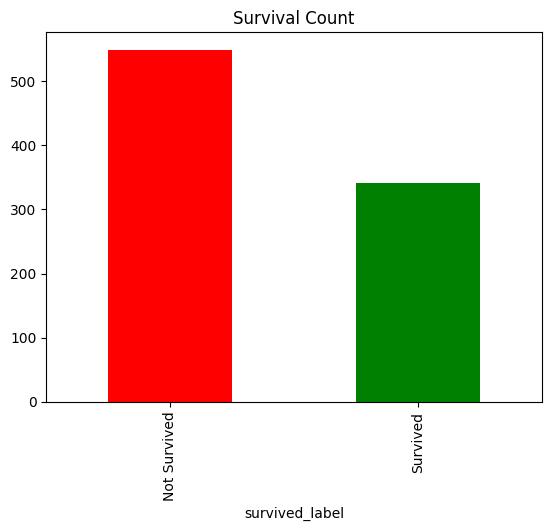

In [11]:
df['survived_label'] = df['survived'].map({0: 'Not Survived', 1: 'Survived'})

df['survived_label'].value_counts().plot(
    kind='bar',
    color=['red', 'green'],
    title='Survival Count'
)

In [12]:
#most of the passengers did not survive, as shown by the bar chart.
df['survived'].value_counts(normalize=True) * 100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

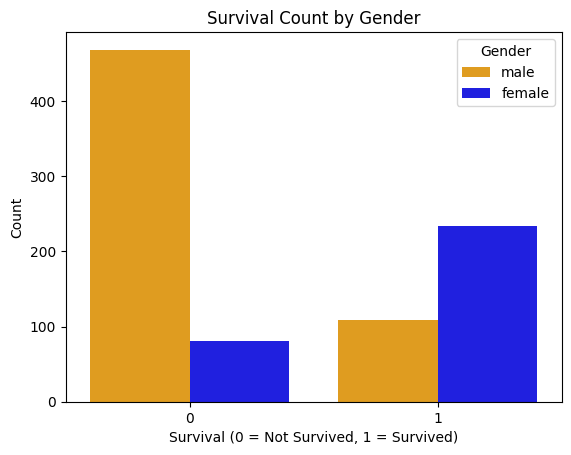

In [ ]:
# surival rate is 38.38% and non-survival rate is 61.62%
sns.countplot(
    x='survived',
    hue='sex',
    data=df,
    palette={'male': 'orange', 'female': 'blue'}
)

plt.title('Survival Count by Gender')
plt.xlabel(' (0 = Not Survived, 1 = Survived)')
plt.ylabel('Count')

plt.legend(title='Gender')
plt.show()

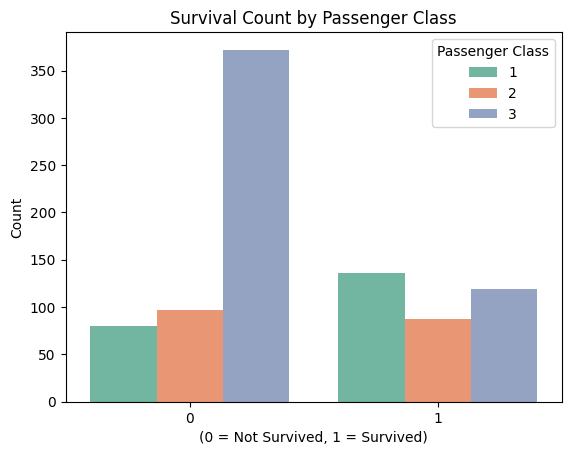

In [18]:
# here we can see that a higher proportion of females survived compared to males which is consistent with the 
# historical accounts of the Titanic disaster where women and children were given priority for lifeboats.
sns.countplot(
    x='survived', 
    hue='pclass', 
    data=df, 
    palette='Set2')
plt.title('Survival Count by Passenger Class')
plt.xlabel('(0 = Not Survived, 1 = Survived)')
plt.ylabel('Count') 
plt.legend(title='Passenger Class')
plt.show()

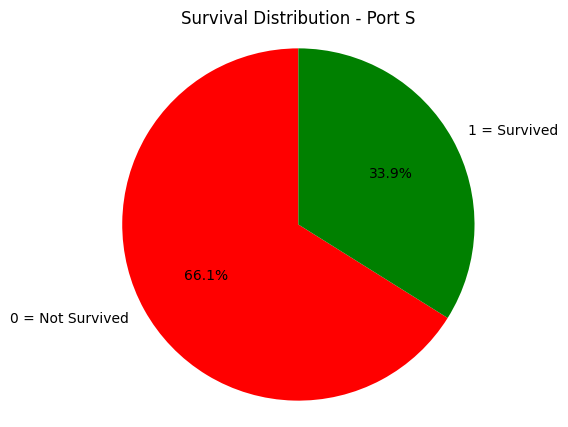

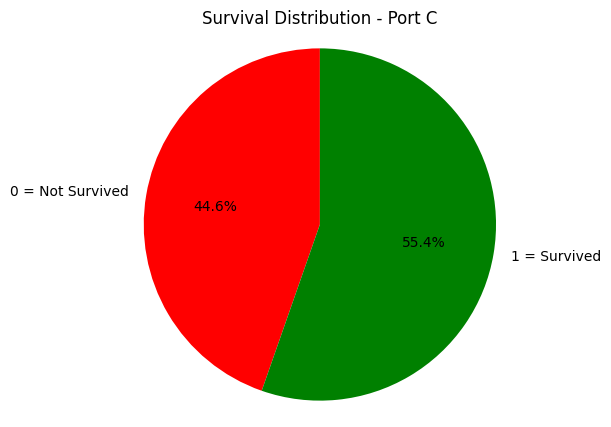

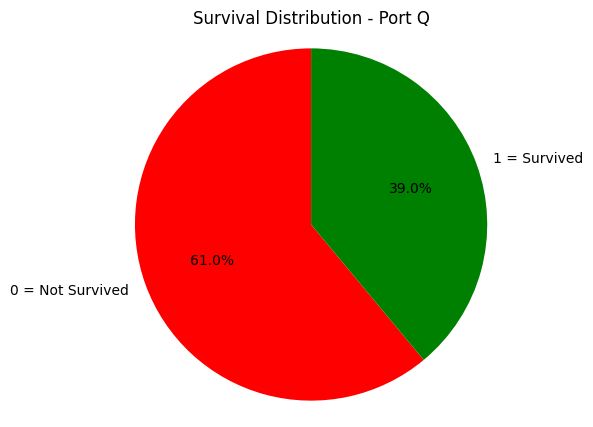

In [25]:
# here we can see that a higher proportion of first-class passengers 
# survived compared to second and third-class passengers,
# which is also consistent with historical accounts of the 
# Titanic disaster where first-class passengers had better access to lifeboats and were more likely to survive.
ports = df['embarked'].dropna().unique()

for port in ports:
    data = df[df['embarked'] == port]['survived'].value_counts().sort_index()
    
    labels = ['0 = Not Survived', '1 = Survived']
    
    plt.figure(figsize=(5,5))
    plt.pie(
        data,
        labels=labels,
        autopct='%1.1f%%',
        colors=['red', 'green'],   # 2 classes → 2 colors
        startangle=90
    )
    
    plt.title(f'Survival Distribution - Port {port}')
    plt.axis('equal')
    plt.show()

In [26]:
#here we can see that passengers who embarked from port C (Cherbourg) had a higher survival rate compared to 
# those who embarked from ports S (Southampton) and Q (Queenstown). 
# This could be due to various factors such as the location of the cabins, 
# the proximity to lifeboats, or the demographics of the passengers boarding at each port.
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'survived_label'],
      dtype='object')

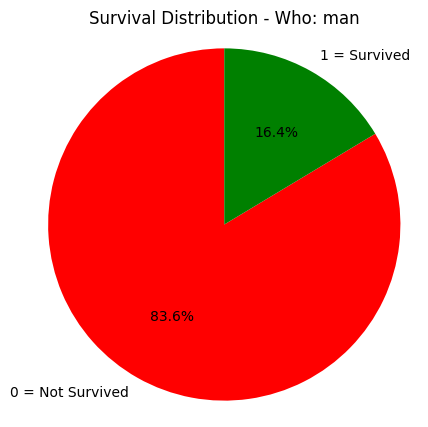

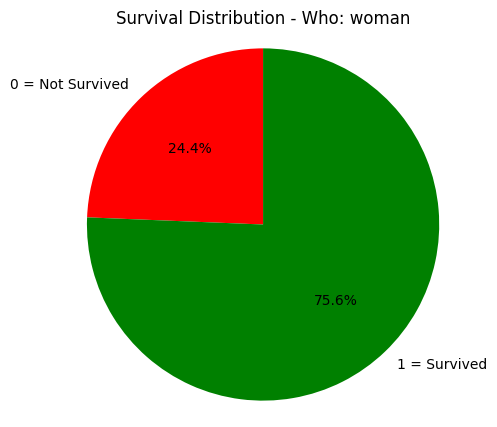

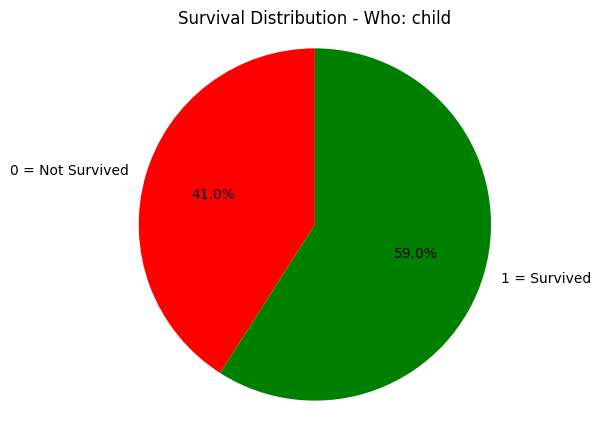

In [28]:
import matplotlib.pyplot as plt

groups = df['who'].dropna().unique()

for group in groups:
    data = df[df['who'] == group]['survived'].value_counts().sort_index()
    
    labels = ['0 = Not Survived', '1 = Survived']
    
    plt.figure(figsize=(5,5))
    plt.pie(
        data,
        labels=labels,
        autopct='%1.1f%%',
        colors=['red', 'green'],
        startangle=90
    )
    
    plt.title(f'Survival Distribution - Who: {group}')
    plt.axis('equal')
    plt.show()

In [ ]:
#here we can see that passengers who are females had a significantly higher survival percentage compared to 
# children and males 